# Logistic Regression Part 4: Loss Function, Maximum Likelihood, and Binary Cross Entropy

## 1. Why Do We Need a Loss Function?

In Logistic Regression, the output is a probability:

$$
\hat{y} = \sigma(z)
$$

where

$$
z = wx + b
$$

and

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The predicted probability $\hat{y}$ lies between 0 and 1.

To train the model, we need a way to measure how good or bad the predictions are. This is done using a **Loss Function**.

---

## 2. Why Mean Squared Error (MSE) is Not Preferred

A simple idea is to use:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

However, for Logistic Regression:

- MSE creates a non-convex optimization problem.
- Gradient descent may get stuck.
- Training becomes inefficient.

Therefore, Logistic Regression uses **Maximum Likelihood Estimation (MLE)** and **Binary Cross Entropy (BCE)**.

---

# 3. Maximum Likelihood Estimation (MLE)

The main idea:

> Choose the parameters $(w,b)$ that maximize the probability of observing the given training data.

---

## Probability of a Single Observation

For a binary classification problem:

### If $y=1$

The probability of observing the sample is:

$$
P(y=1|x)=\hat{y}
$$

### If $y=0$

The probability of observing the sample is:

$$
P(y=0|x)=1-\hat{y}
$$

These can be combined into one equation:

$$
P(y|x)=\hat{y}^{\,y}(1-\hat{y})^{(1-y)}
$$

---

## Likelihood Function

For $n$ independent observations:

$$
L(w,b)
=
\prod_{i=1}^{n}
\hat{y}_i^{\,y_i}
(1-\hat{y}_i)^{(1-y_i)}
$$

This is called the **Likelihood Function**.

Goal:

$$
\max L(w,b)
$$

---

# 4. Log-Likelihood

Working with products is difficult.

Take the logarithm:

$$
\log L(w,b)
=
\sum_{i=1}^{n}
\left[
y_i \log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

This is called the **Log-Likelihood Function**.

Goal:

$$
\max \log L(w,b)
$$

---

# 5. From Maximum Likelihood to Loss Function

Machine learning algorithms usually **minimize** a loss.

Therefore, instead of maximizing log-likelihood, we minimize its negative.

$$
Loss
=
-\log L(w,b)
$$

Thus,

$$
Loss
=
-
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

This is called **Binary Cross Entropy Loss**.

---

# 6. Binary Cross Entropy (BCE)

For a single training example:

$$
L(y,\hat{y})
=
-
\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
$$

This is the most important loss function in Logistic Regression.

---

## BCE for Multiple Samples

For $n$ samples:

$$
J(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

- $y_i$ = Actual label
- $\hat{y}_i$ = Predicted probability
- $n$ = Number of samples

---

# 7. Understanding BCE

### Case 1: Correct Prediction

Actual:

$$
y = 1
$$

Prediction:

$$
\hat{y}=0.99
$$

Loss:

$$
L = -\log(0.99)
$$

$$
L \approx 0.01
$$

Very small loss.

---

### Case 2: Wrong Prediction

Actual:

$$
y = 1
$$

Prediction:

$$
\hat{y}=0.01
$$

Loss:

$$
L = -\log(0.01)
$$

$$
L \approx 4.605
$$

Very large loss.

---

## Interpretation

- Correct predictions → Small loss
- Wrong predictions → Large loss
- Confident wrong predictions → Extremely large loss

Thus BCE strongly penalizes bad predictions.

---

# 8. Why Binary Cross Entropy Works Well

### Advantages

1. Convex optimization problem.
2. Works naturally with probabilities.
3. Derived from Maximum Likelihood Estimation.
4. Provides efficient gradients.
5. Standard loss function for Logistic Regression.

---

# 9. Complete Flow of Logistic Regression

### Step 1

Compute linear equation:

$$
z = wx + b
$$

### Step 2

Apply sigmoid function:

$$
\hat{y}
=
\frac{1}{1+e^{-z}}
$$

### Step 3

Compute Binary Cross Entropy:

$$
L(y,\hat{y})
=
-
\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
$$

### Step 4

Use Gradient Descent to minimize the loss.

### Step 5

Update parameters:

$$
w = w - \eta \frac{\partial J}{\partial w}
$$

$$
b = b - \eta \frac{\partial J}{\partial b}
$$

until the loss becomes minimum.

---

# Key Formulas Summary

### Sigmoid Function

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

### Probability Model

$$
P(y|x)
=
\hat{y}^{\,y}
(1-\hat{y})^{(1-y)}
$$

### Likelihood Function

$$
L(w,b)
=
\prod_{i=1}^{n}
\hat{y}_i^{\,y_i}
(1-\hat{y}_i)^{(1-y_i)}
$$

### Log-Likelihood

$$
\log L(w,b)
=
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

### Binary Cross Entropy (Single Sample)

$$
L(y,\hat{y})
=
-
\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
$$

### Binary Cross Entropy (Dataset)

$$
J(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [2]:
import matplotlib.pyplot as plt

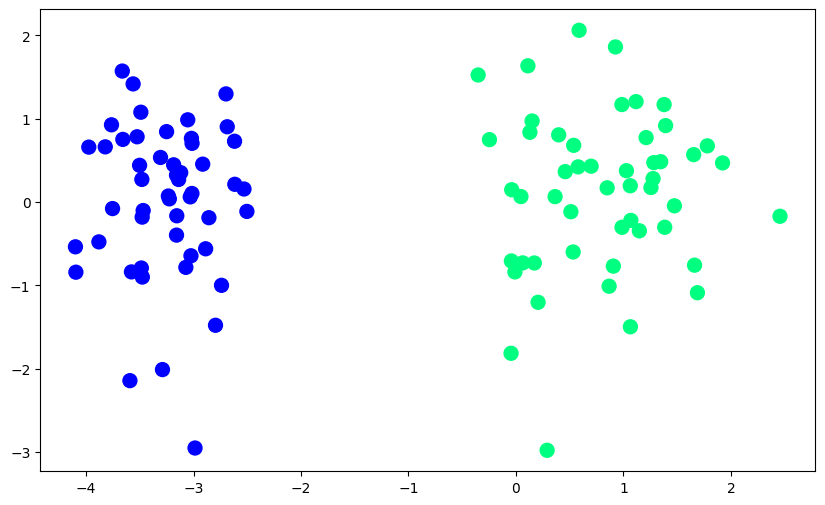

In [3]:

plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [6]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(
    penalty=None,
    solver='sag'
)

lor.fit(X, y)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [7]:
print(lor.coef_)
print(lor.intercept_)

[[5.16406091 0.30154577]]
[5.08820592]


In [8]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [9]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [46]:
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(500):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]

In [47]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [48]:
coef_,intercept_ = gd(X,y)


In [49]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])


In [50]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

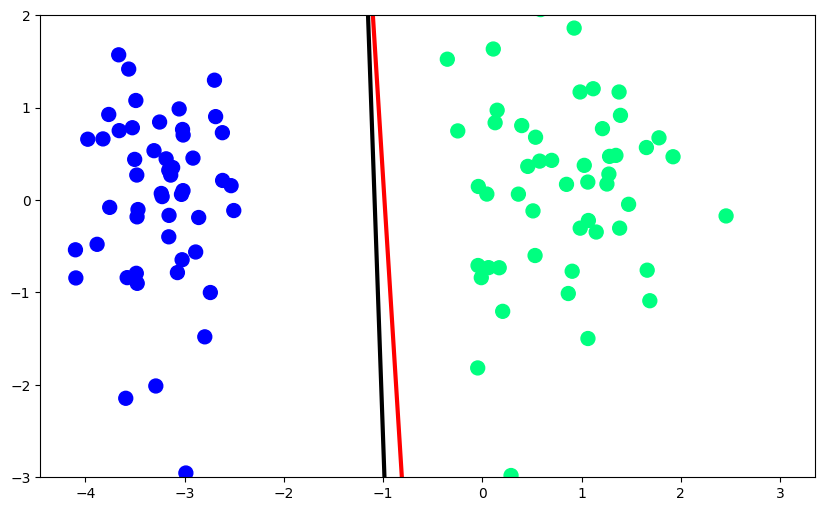

In [51]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)